This data is from https://madnight.github.io/githut/#/pull_requests/2024/1

In [ ]:
import pandas as pd


push_df=pd.read_csv("gh-push-event.json.csv")
lic_df=pd.read_csv("github-lic.csv")




In [2]:
lic_df

,license,count
0,mit,1551711
1,apache-2.0,455316
2,gpl-2.0,376453
3,gpl-3.0,284761
4,bsd-3-clause,161041
5,bsd-2-clause,57412
6,unlicense,43899
7,lgpl-3.0,38213
8,agpl-3.0,38034
9,cc0-1.0,28600


In [3]:
push_df

,name,year,quarter,count
0,JavaScript,2012,2,98729
1,Python,2012,2,89650
2,Ruby,2012,2,87701
3,Java,2012,2,64086
4,PHP,2012,2,62896
...,...,...,...,...
4748,Cython,2024,1,199
4749,Twig,2024,1,193
4750,MLIR,2024,1,191
4751,Sass,2024,1,190


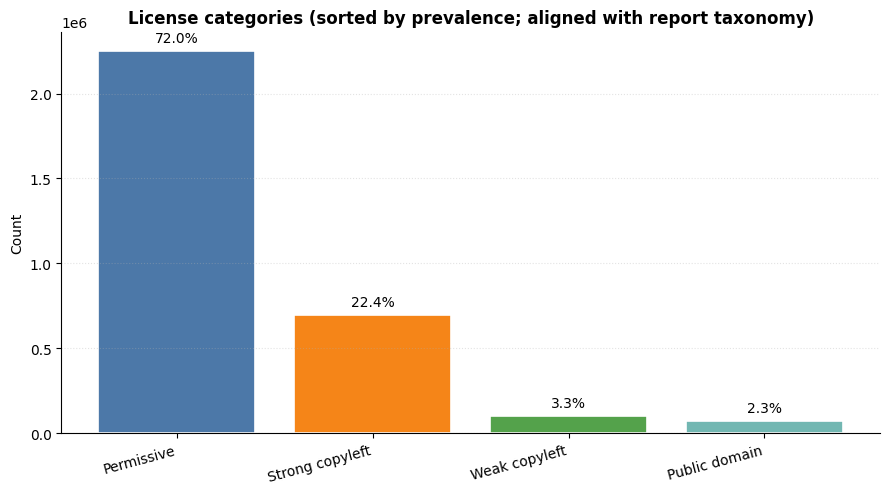

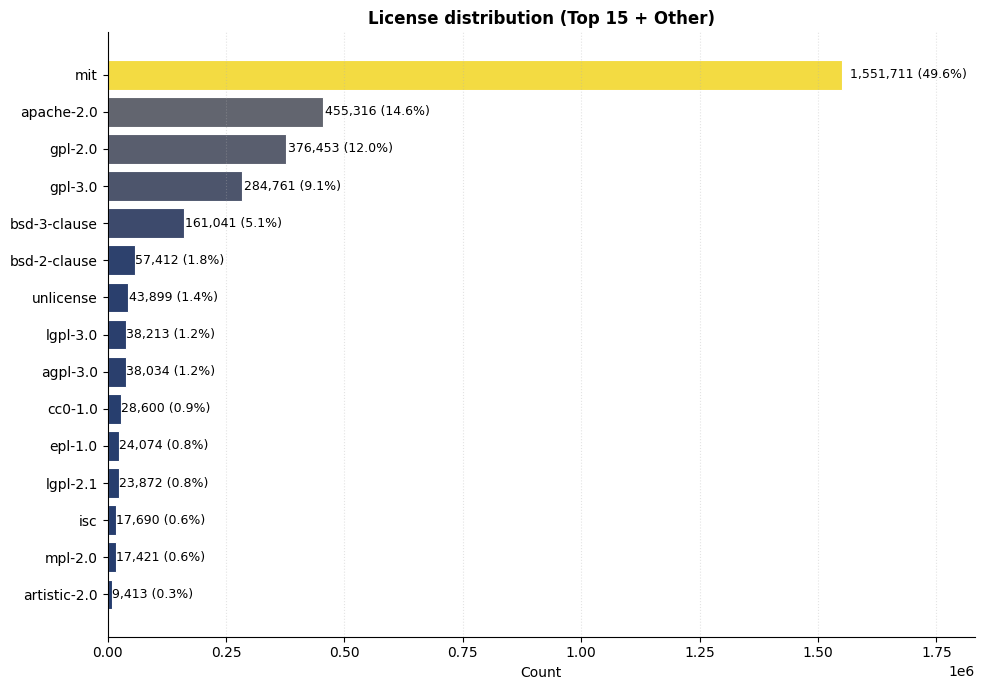

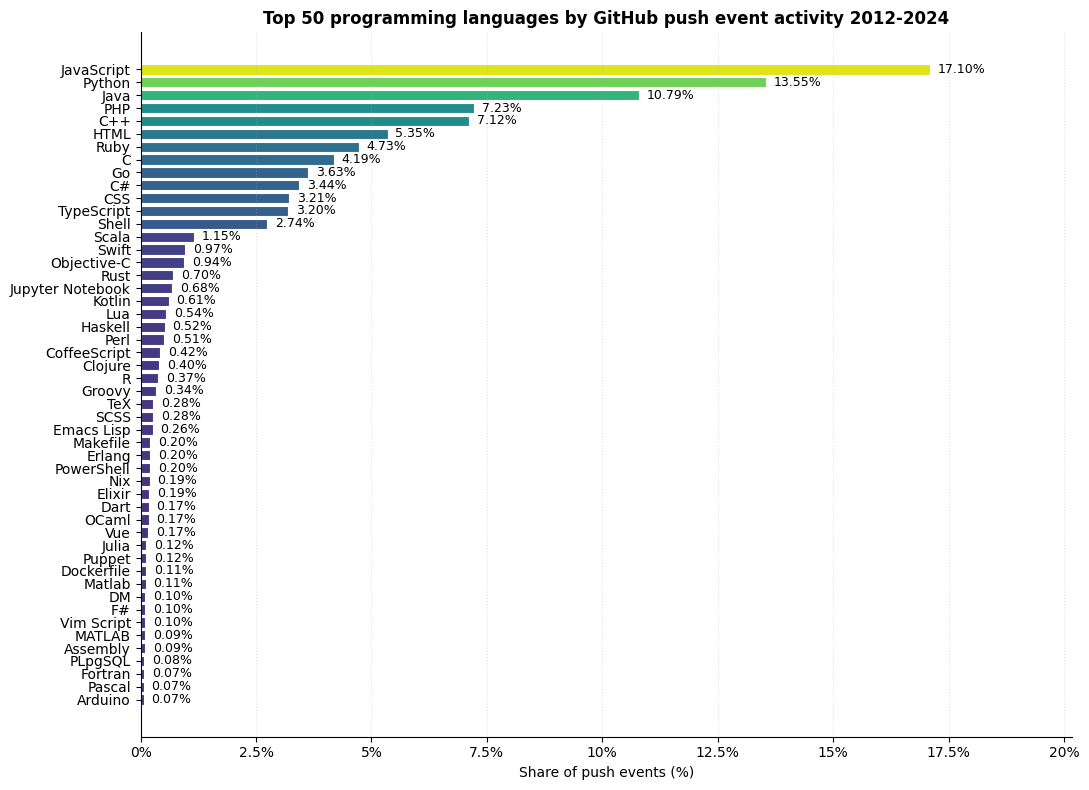

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

OUTDIR = Path("figures_githut")
OUTDIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

# ---------- helpers ----------
def top_n_with_other(df, label_col, value_col, n=15, other_label="Other"):
    d = df[[label_col, value_col]].copy()
    d[value_col] = pd.to_numeric(d[value_col], errors="coerce").fillna(0).astype(int)
    d = d.sort_values(value_col, ascending=False)
    top = d.head(n).copy()
    other_sum = d.iloc[n:][value_col].sum()
    if other_sum > 0:
        top = pd.concat([top, pd.DataFrame({label_col:[other_label], value_col:[other_sum]})], ignore_index=True)
    top["share_pct"] = 100 * top[value_col] / top[value_col].sum()
    return top

# ---------- LICENSE CATEGORIES (sorted desc + nicer style + colors) ----------
def license_to_category(lic: str) -> str:
    lic = str(lic).lower().strip()
    public_domain = {"unlicense", "cc0-1.0", "wtfpl"}
    permissive = {"mit", "apache-2.0", "bsd-3-clause", "bsd-2-clause", "isc", "zlib", "bsl-1.0", "afl-3.0", "artistic-2.0"}
    weak_copyleft = {"mpl-2.0", "epl-1.0", "epl-2.0", "lgpl-2.1", "lgpl-3.0"}
    strong_copyleft = {"gpl-2.0", "gpl-3.0", "agpl-3.0"}

    if lic in public_domain: return "Public domain"
    if lic in permissive: return "Permissive"
    if lic in weak_copyleft: return "Weak copyleft"
    if lic in strong_copyleft: return "Strong copyleft"
    return "Other / not classified"

lic_cat = lic_df.copy()
lic_cat["count"] = pd.to_numeric(lic_cat["count"], errors="coerce").fillna(0).astype(int)
lic_cat["category"] = lic_cat["license"].apply(license_to_category)

cat = (lic_cat.groupby("category", as_index=False)["count"].sum()
              .sort_values("count", ascending=False))
cat["share_pct"] = 100 * cat["count"] / cat["count"].sum()

cat_colors = {
    "Permissive": "#4C78A8",
    "Strong copyleft": "#F58518",
    "Weak copyleft": "#54A24B",
    "Public domain": "#72B7B2",
    "Other / not classified": "#B279A2",
}
colors = [cat_colors.get(c, "#999999") for c in cat["category"]]

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(cat["category"], cat["count"], color=colors, edgecolor="white", linewidth=1.2)

ymax = cat["count"].max()
for b, pct in zip(bars, cat["share_pct"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015*ymax, f"{pct:.1f}%",
            ha="center", va="bottom", fontsize=10)

ax.set_title("License categories (sorted by prevalence; aligned with report taxonomy)")
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.grid(axis="y", linestyle=":", alpha=0.35)
plt.xticks(rotation=15, ha="right")

fig.tight_layout()
fig.savefig(OUTDIR / "license_categories_sorted.png", dpi=300)
plt.show()


# ---------- LICENSE DISTRIBUTION (names) TOP 15 + Other ----------
lic_top = top_n_with_other(lic_df, "license", "count", n=15, other_label="Other")
lic_top_sorted = lic_top.sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

norm = (lic_top_sorted["count"] - lic_top_sorted["count"].min()) / (lic_top_sorted["count"].max() - lic_top_sorted["count"].min() + 1e-9)
lic_colors = plt.cm.cividis(0.15 + 0.8 * norm.values)

ax.barh(
    lic_top_sorted["license"],
    lic_top_sorted["count"],
    color=lic_colors,
    edgecolor="white",
    linewidth=0.8
)

# add count + percent labels for every bar
xmax = lic_top_sorted["count"].max()
ax.set_xlim(0, xmax * 1.18)
for y, (v, p) in enumerate(zip(lic_top_sorted["count"], lic_top_sorted["share_pct"])):
    ax.text(v * 1.01, y, f"{v:,} ({p:.1f}%)", va="center", fontsize=9)

ax.set_title("License distribution (Top 15 + Other)")
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.grid(axis="x", linestyle=":", alpha=0.35)

fig.tight_layout()
fig.savefig(OUTDIR / "license_distribution_top15.png", dpi=300)
plt.show()


# ---------- LANGUAGE DISTRIBUTION (TOP 50 overall + TOP 50 in 2024) ----------
df = push_df.copy()
df["count"] = pd.to_numeric(df["count"], errors="coerce").fillna(0).astype(int)
df["year"]  = pd.to_numeric(df["year"],  errors="coerce").fillna(0).astype(int)

def plot_top50_lang_share(dataframe, title, outfile, cmap=plt.cm.viridis):
    lang_total = (
        dataframe.groupby("name", as_index=False)["count"]
                 .sum()
                 .sort_values("count", ascending=False)
                 .head(50)
                 .copy()
    )

    total_all = dataframe["count"].sum()
    lang_total["share"] = lang_total["count"] / total_all
    lang_total["share_pct"] = 100 * lang_total["share"]

    # reverse for barh
    names = lang_total["name"][::-1].tolist()
    vals  = lang_total["share_pct"][::-1].tolist()

    fig, ax = plt.subplots(figsize=(11, 8))

    # gradient coloring by magnitude
    norm = (lang_total["share_pct"] - lang_total["share_pct"].min()) / (lang_total["share_pct"].max() - lang_total["share_pct"].min() + 1e-12)
    colors = cmap(0.15 + 0.8 * norm.values)

    ax.barh(
        names, vals,
        color=colors[::-1],
        edgecolor="white",
        linewidth=0.8
    )

    ax.set_title(title)
    ax.set_xlabel("Share of push events (%)")
    ax.set_ylabel("")

    # nicer tick formatting: 0.1%, 1%, 10% ...
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}%"))
    ax.grid(axis="x", linestyle=":", alpha=0.35)

    # room for labels
    ax.set_xlim(0, max(vals) * 1.18)

    # annotate ALL bars with percent (and optionally counts)
    for y, v in enumerate(vals):
        ax.text(v + max(vals) * 0.01, y, f"{v:.2f}%", va="center", fontsize=9)

    fig.tight_layout()
    fig.savefig(OUTDIR / outfile, dpi=300)
    plt.show()

# 2012-2024
plot_top50_lang_share(
    df,
    "Top 50 programming languages by GitHub push event activity 2012-2024",
    "language_distribution_top50_share.png",
    cmap=plt.cm.viridis
)

